# Деревья решений

## Решение задачи классификации

In [1]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Создаём сложный датасет
X, y = make_classification(
    n_samples=1000,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_classes=4,
    n_clusters_per_class=1,
    class_sep=0.5,
    random_state=42
)

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# Инициализация дерева
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)
print(f"Accuracy: {clf.score(X_test, y_test):.2f}")

Accuracy: 0.66


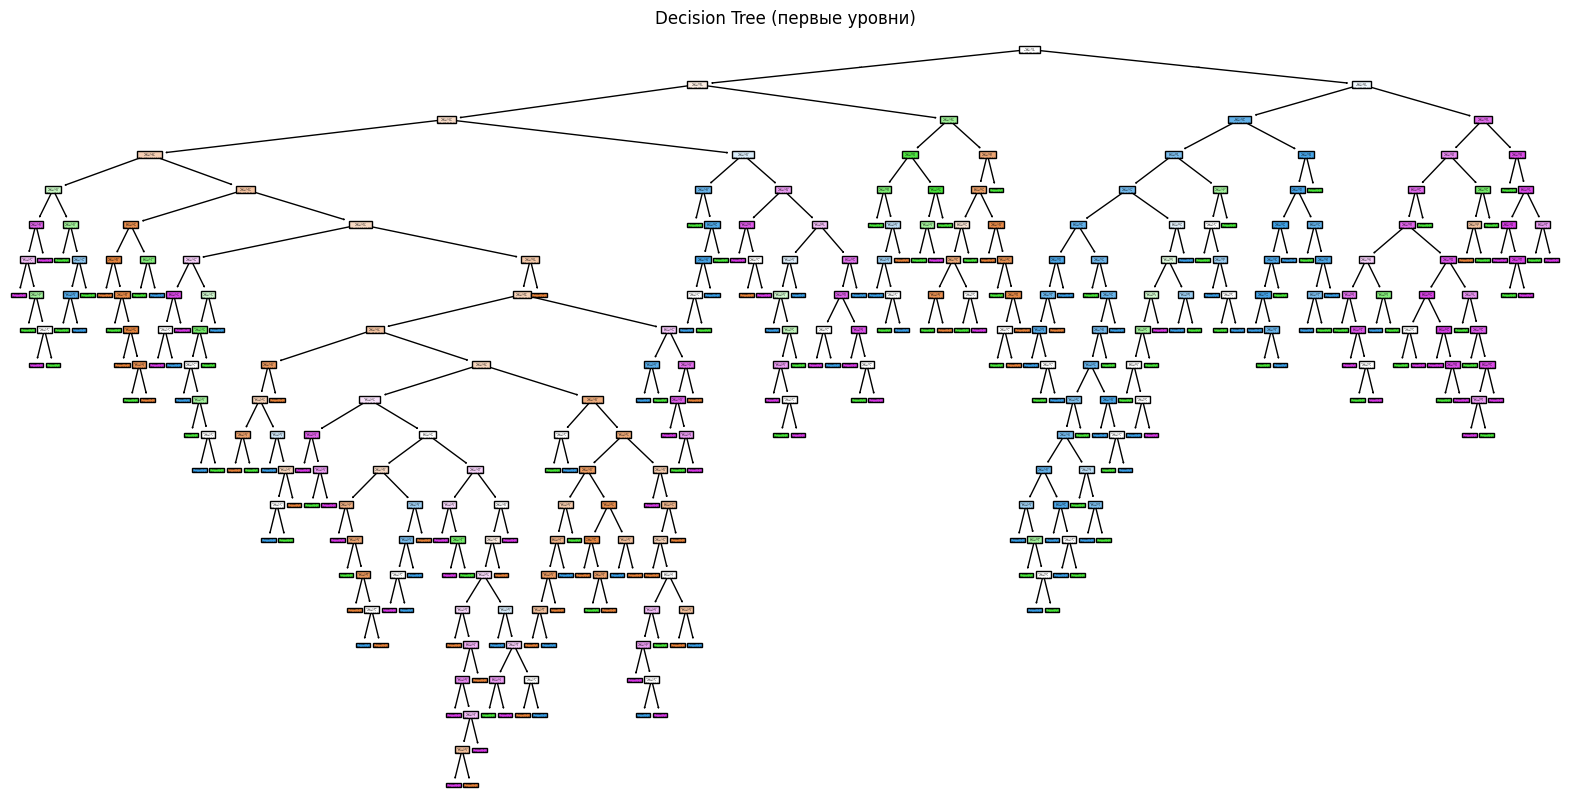

In [2]:
plt.figure(figsize=(20, 10))
plot_tree(clf, filled=True)
plt.title("Decision Tree (первые уровни)")
plt.show()

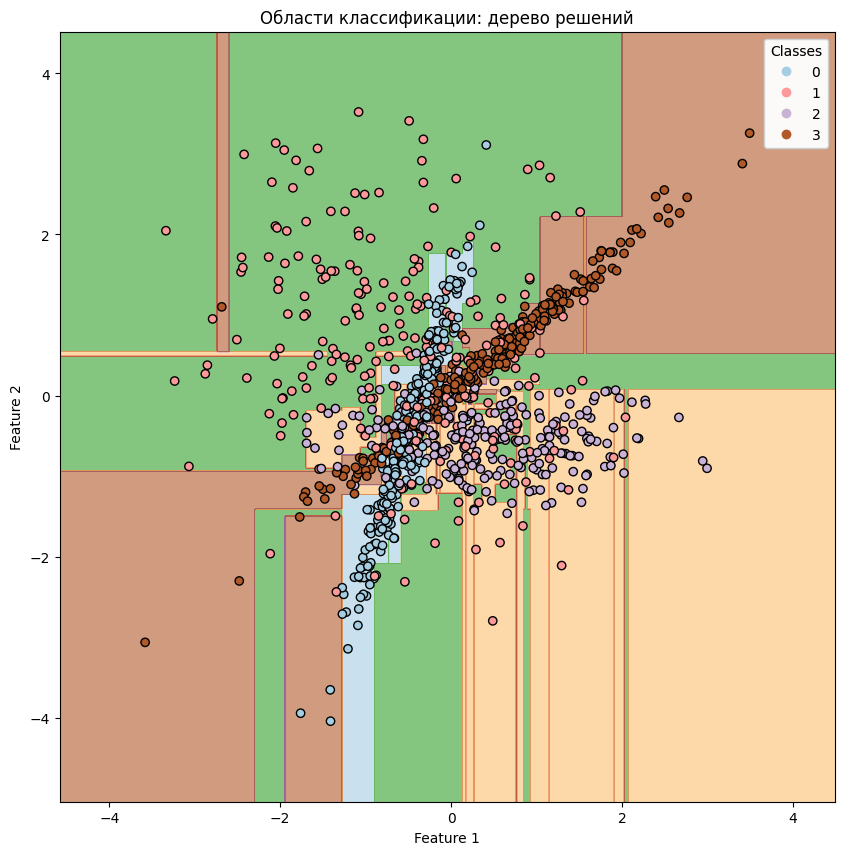

In [3]:
# Визуализация областей классификации
def plot_decision_boundaries(model, X, y, ax=None, title="Decision Boundaries"):
    if ax is None:
        ax = plt.gca()
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.6, cmap=plt.cm.Paired)
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", cmap=plt.cm.Paired)
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    legend = ax.legend(*scatter.legend_elements(), loc="upper right", title="Classes")
    ax.add_artist(legend)

# Построение графика областей классификации
plt.figure(figsize=(10, 10))
plot_decision_boundaries(clf, X, y)
plt.title("Области классификации: дерево решений")
plt.show()

## Pre-pruning

In [4]:
clf_prepruned = DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42)
clf_prepruned.fit(X_train, y_train)

print(f"Accuracy (pre-pruned): {clf_prepruned.score(X_test, y_test):.2f}")

Accuracy (pre-pruned): 0.68


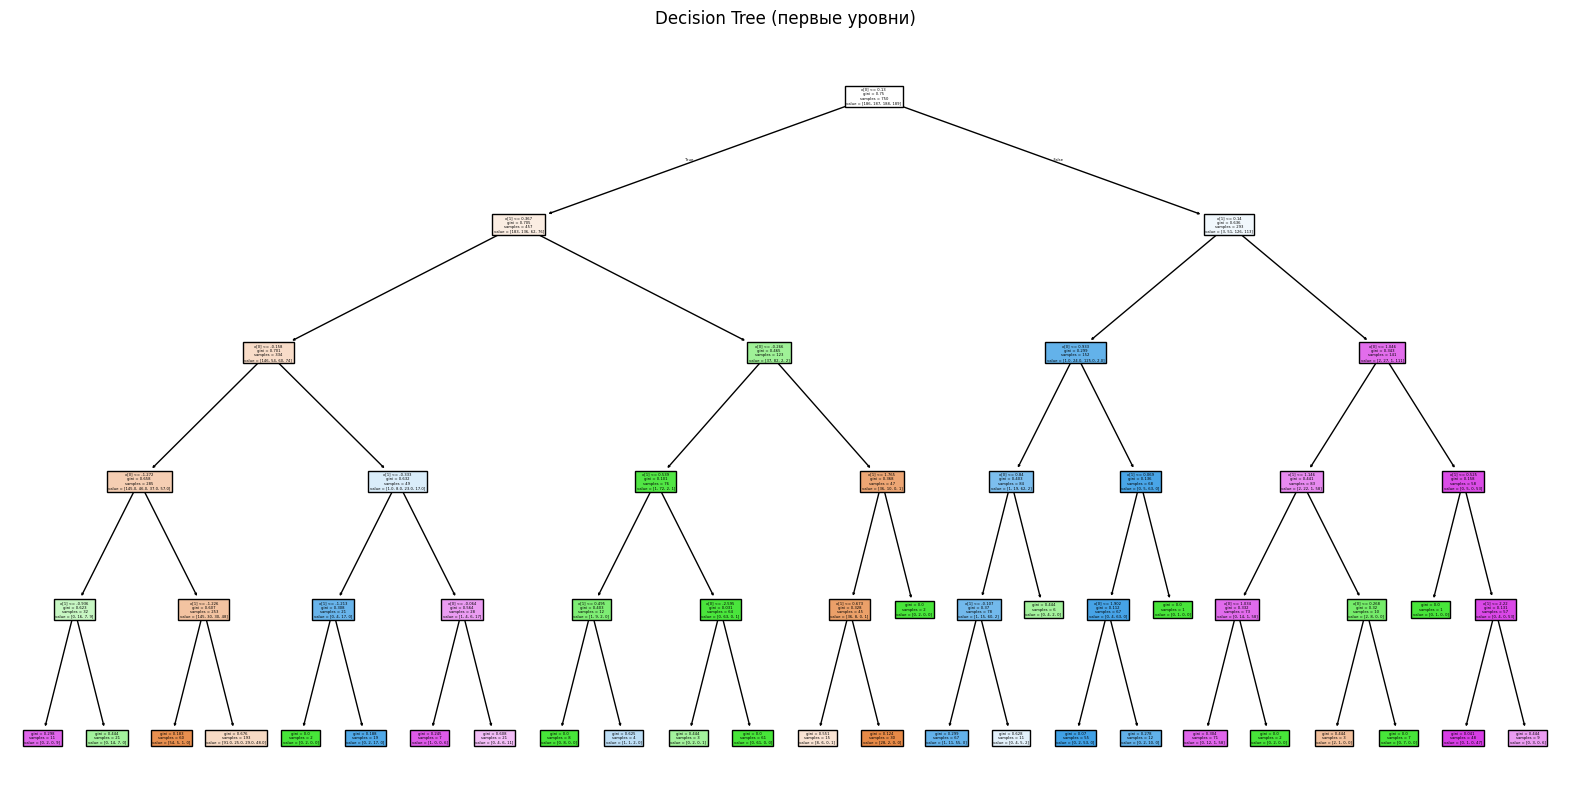

In [5]:
plt.figure(figsize=(20, 10))
plot_tree(clf_prepruned, filled=True)
plt.title("Decision Tree (первые уровни)")
plt.show()

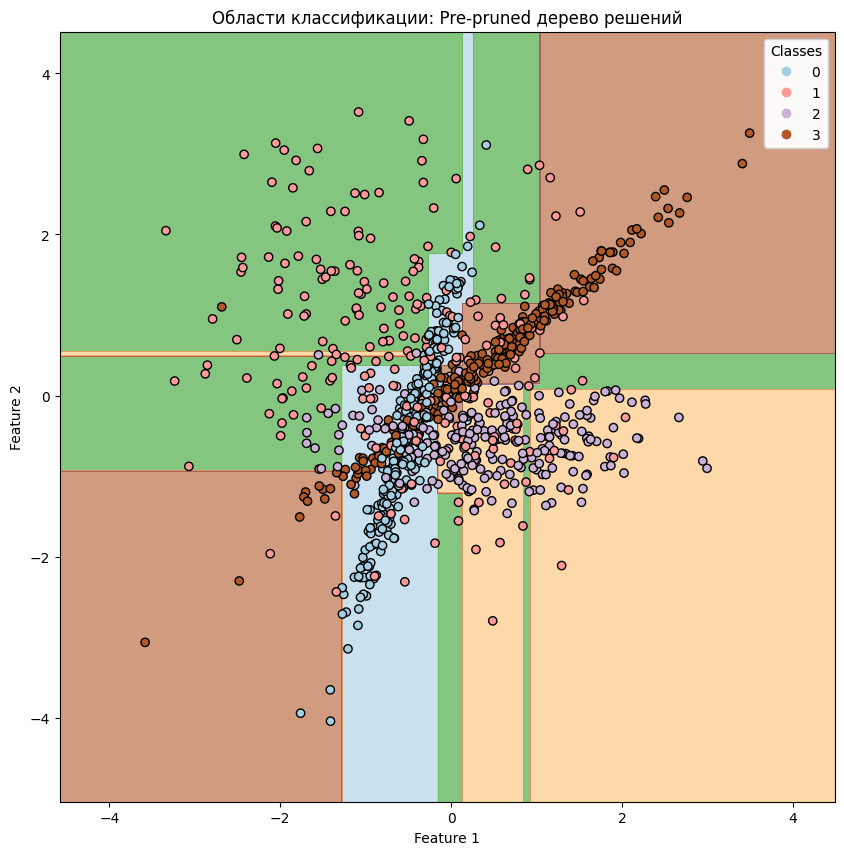

In [6]:
plt.figure(figsize=(10, 10))
plot_decision_boundaries(clf_prepruned, X, y)
plt.title("Области классификации: Pre-pruned дерево решений")
plt.show()

## Post-pruning

In [7]:
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

# Тестируем несколько деревьев с разными alpha
clfs = [DecisionTreeClassifier(random_state=42, ccp_alpha=alpha).fit(X_train, y_train) for alpha in ccp_alphas]

# Оцениваем на тесте
test_scores = [clf.score(X_test, y_test) for clf in clfs]

# Выбираем лучшее
best_index = np.argmax(test_scores)
best_alpha = ccp_alphas[best_index]
print(f"Best alpha: {best_alpha:.4f}, Accuracy: {test_scores[best_index]:.2f}")

Best alpha: 0.0070, Accuracy: 0.73


In [8]:
clf_postpruned = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha).fit(X_train, y_train)

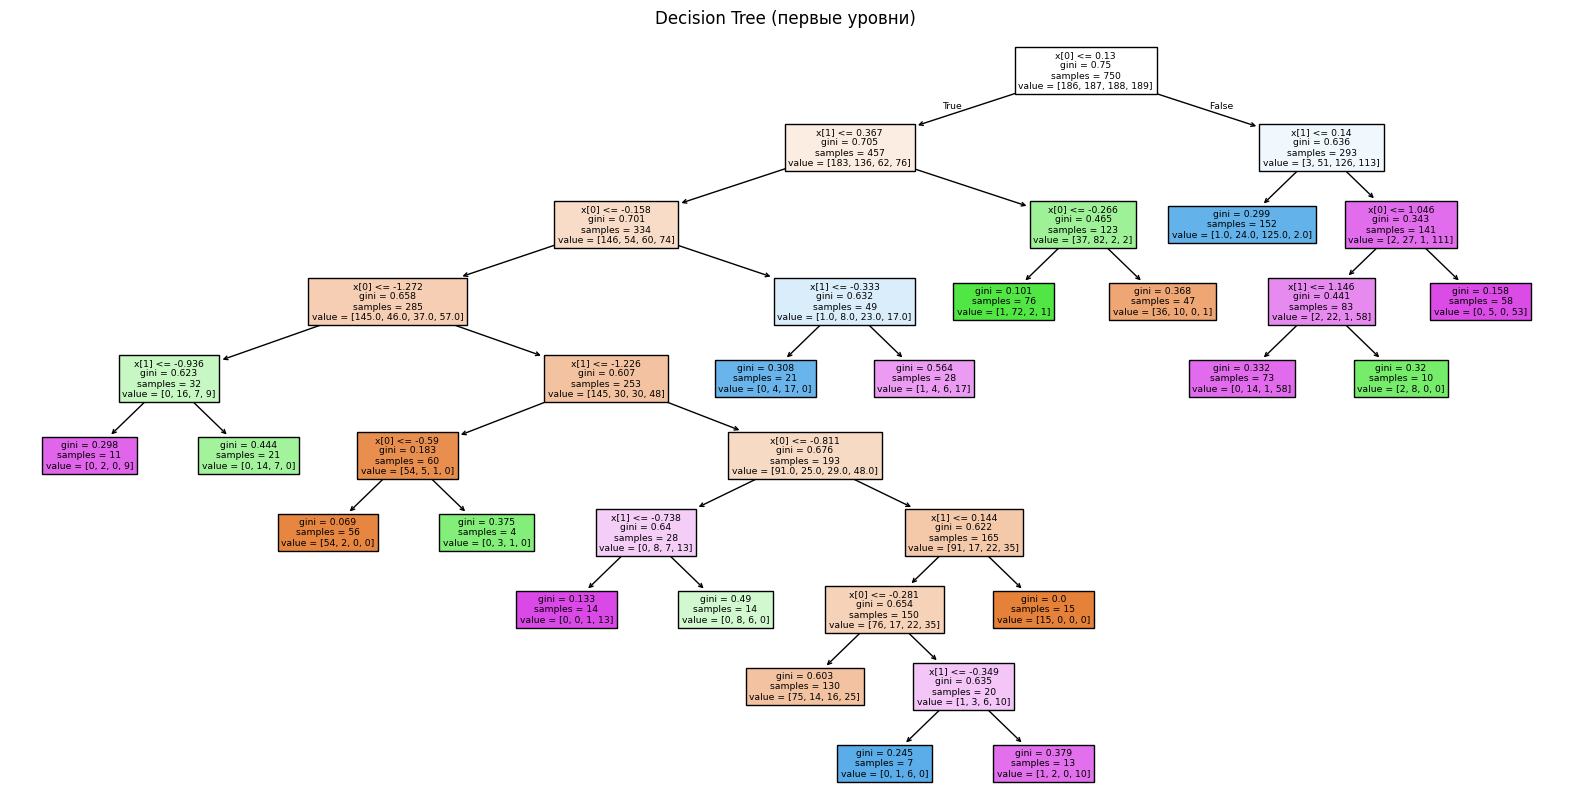

In [9]:
plt.figure(figsize=(20, 10))
plot_tree(clf_postpruned, filled=True)
plt.title("Decision Tree (первые уровни)")
plt.show()

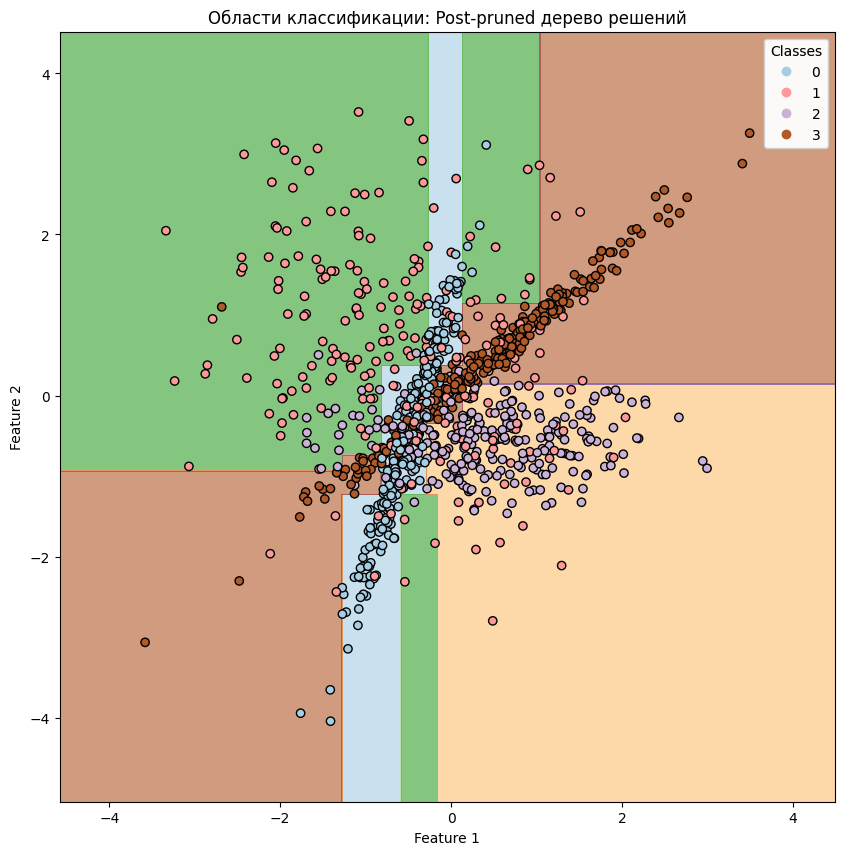

In [10]:
plt.figure(figsize=(10, 10))
plot_decision_boundaries(clf_postpruned, X, y)
plt.title("Области классификации: Post-pruned дерево решений")
plt.show()

## Поиск по сетке лучших гиперпараметров (поиск лучшей регуляризации)

In [11]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [1, 2, 5, 10, 15, None],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_leaf_nodes': [None, 10, 20, 30, 50]
}

grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Best params: {grid_search.best_params_}")
print(f"Best accuracy: {grid_search.best_score_:.2f}")

Best params: {'max_depth': 10, 'max_leaf_nodes': 30, 'min_samples_leaf': 1}
Best accuracy: 0.74


In [12]:
best_clf = grid_search.best_estimator_

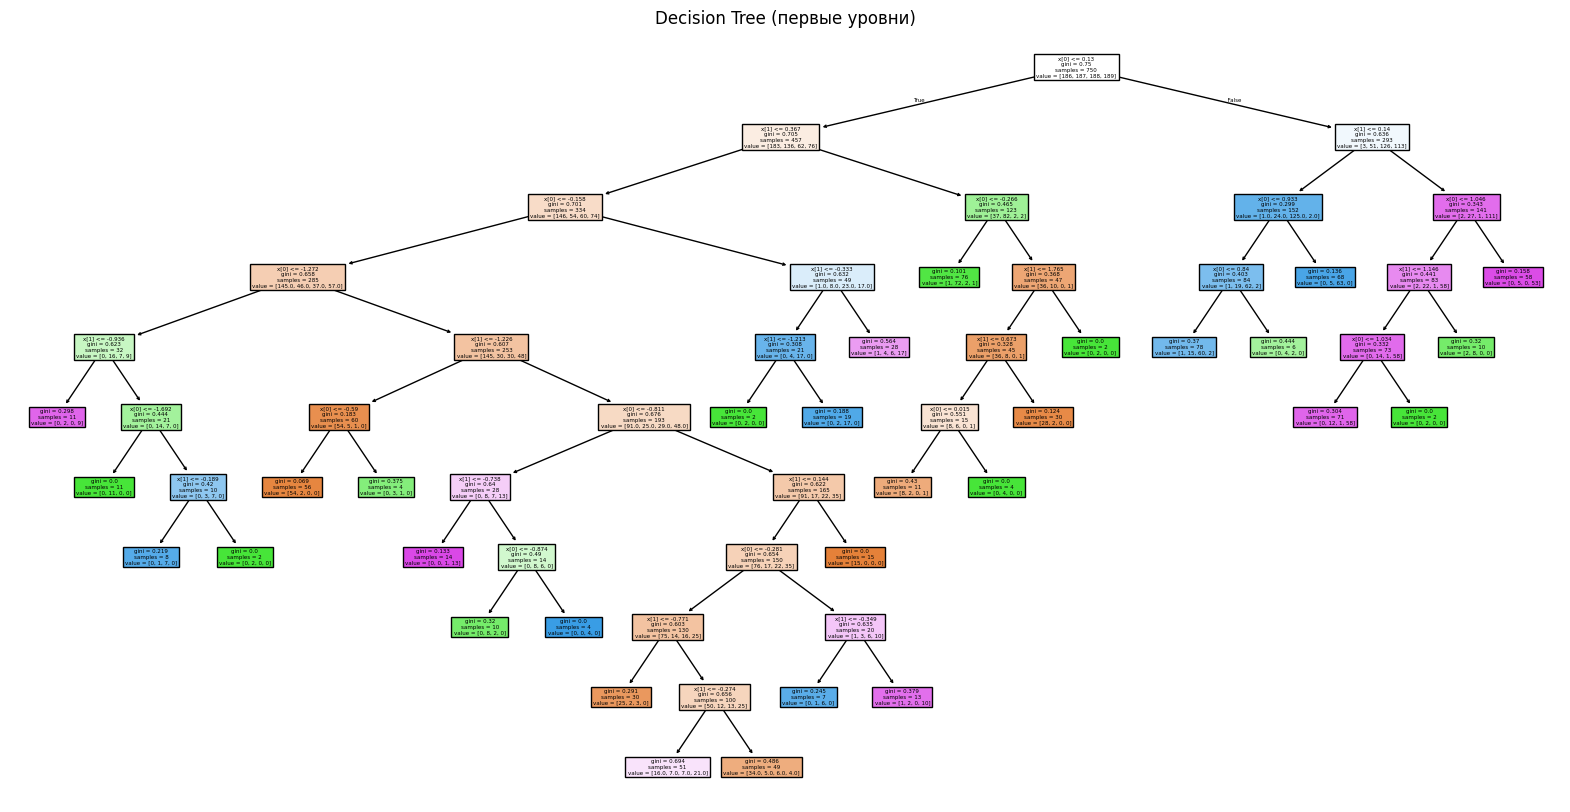

In [13]:
plt.figure(figsize=(20, 10))
plot_tree(best_clf, filled=True)
plt.title("Decision Tree (первые уровни)")
plt.show()

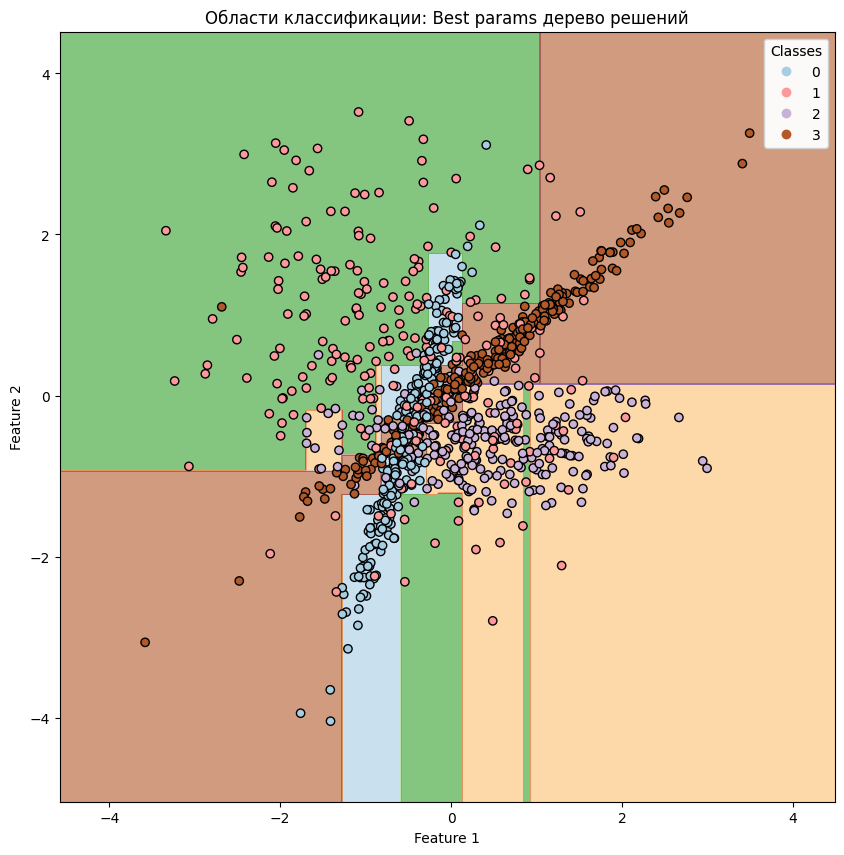

In [14]:
plt.figure(figsize=(10, 10))
plot_decision_boundaries(best_clf, X, y)
plt.title("Области классификации: Best params дерево решений")
plt.show()

## Работа с пропусками

In [15]:
import pandas as pd

# Создаем копию и добавим пропуски
X_missing = X.copy()
rng = np.random.RandomState(42)
missing_mask = rng.rand(*X_missing.shape) < 0.1
X_missing[missing_mask] = np.nan

# Обучим дерево на данных с пропущенными значениями после простой обработки
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X_missing)

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_imputed, y, stratify=y, random_state=42)

clf_postpruned.fit(X_train_m, y_train_m)

print(f"Accuracy with missing values: {clf_postpruned.score(X_test_m, y_test_m):.2f}")

Accuracy with missing values: 0.63


In [16]:
pd.DataFrame(X_missing).sample(10, random_state=40)

,0,1
204,-0.175861,NaN
71,0.033544,0.778521
594,1.284577,-0.716192
672,2.174701,-0.528312
14,1.382030,NaN
64,NaN,0.053602
340,-0.686766,-1.184090
135,0.439899,0.302905
350,1.741449,NaN
976,-0.469268,-0.036559


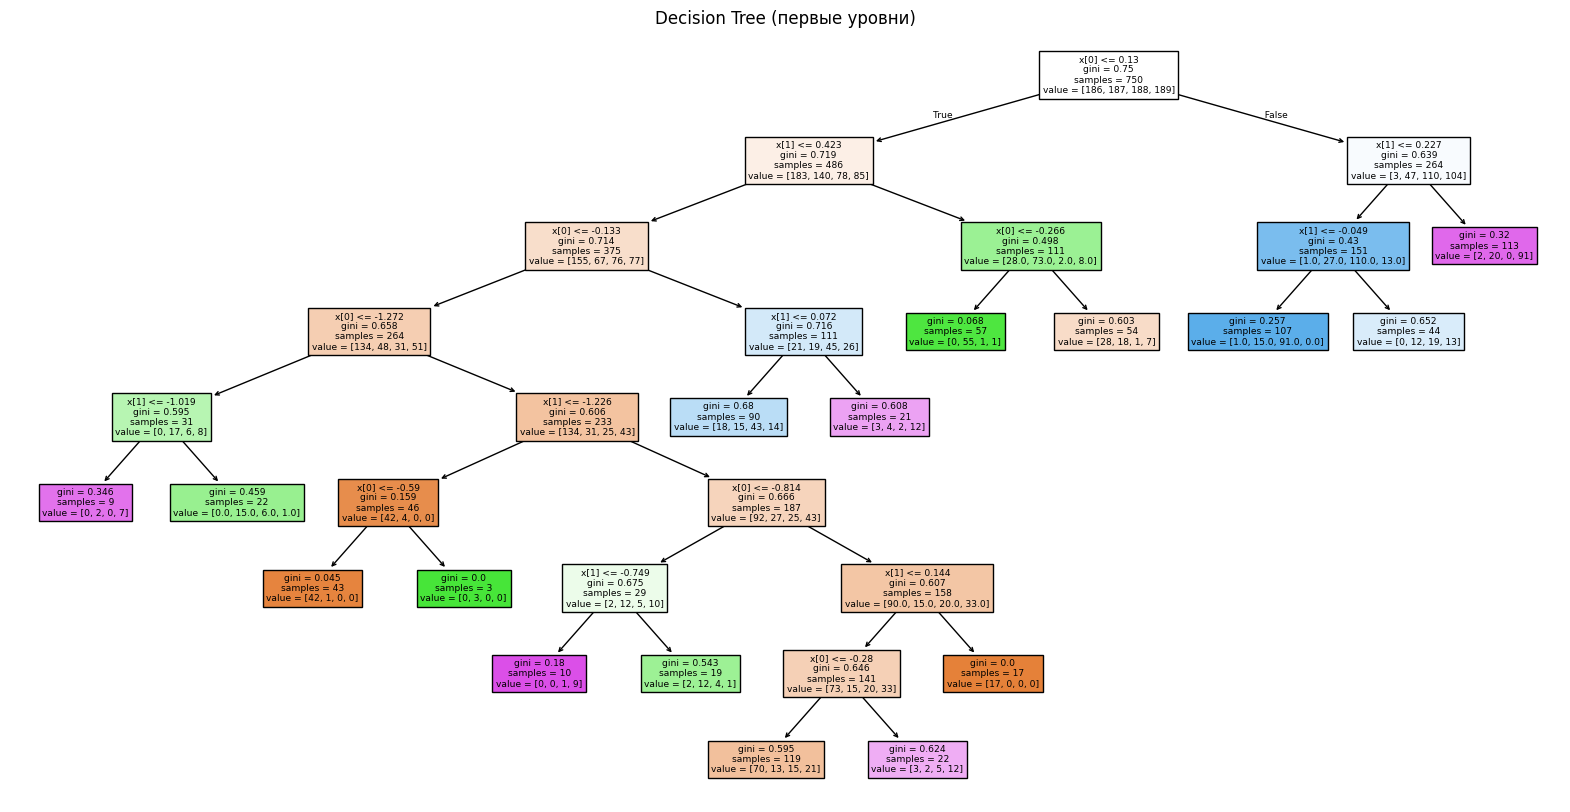

In [17]:
plt.figure(figsize=(20, 10))
plot_tree(clf_postpruned, filled=True)
plt.title("Decision Tree (первые уровни)")
plt.show()

## Неустойчивость дерева

# Домашнее задание: случайный лес на Toyota Corolla


## 1. Разделение выборки и предобработка

**Сделали ли предобработку для случайного леса? Отличается ли она от линейной модели?**

Да, предобработка нужна, но она проще: для леса и дерева мы оставили числовые признаки как есть и сделали только `OneHotEncoder` для категориальных признаков. Масштабирование (`StandardScaler`) для деревьев обычно не требуется, потому что разбиения в деревьях основаны на порогах признаков, а не на расстояниях.

Для линейной регрессии масштабирование числовых признаков полезно, особенно при регуляризации (Ridge/Lasso), поэтому для линейной модели использован отдельный препроцессор с `StandardScaler`.

**Как разделили выборку?**

Сделали `train_test_split(test_size=0.2, random_state=42)`: 80% обучающая и 20% тестовая выборка.

**На сколько частей делить выборку при кросс-валидации?**

Часто берут 5 фолдов (`cv=5`) как разумный компромисс между стабильностью оценки и временем расчета. Иногда берут 3 или 10 в зависимости от размера данных и вычислительных ограничений.

**Можно ли без кросс-валидации?**

Да. Тогда достаточно обычного hold-out разделения (`train/test`), например 80/20 или 70/30. Это быстрее, но оценка качества может быть менее стабильной, чем при CV.

## 2. Анализ: одно дерево vs случайный лес

**Сравнение скорости:**

Обычно одно дерево обучается быстрее леса, потому что в лесе обучается много деревьев (`n_estimators`). В таблице выше это видно по `Fit time`.

**Можно ли добиться близкой скорости?**

Да, если уменьшить `n_estimators`, ограничить `max_depth`, увеличить `min_samples_leaf`, а также использовать `n_jobs=-1` для распараллеливания. Но слишком агрессивное упрощение может снизить качество.

**Сравнение качества:**

Случайный лес почти всегда показывает более высокое качество и меньший разброс на CV (`CV RMSE std`), потому что усреднение большого числа деревьев снижает дисперсию и переобучение по сравнению с одним деревом.

## 3. Оценка качества и сравнение моделей

1. **Какие метрики использованы и почему?**

Использованы `RMSE`, `MAE` и $R^2$.
- `RMSE` сильнее штрафует большие ошибки, поэтому хорошо показывает, когда модель сильно промахивается по цене.
- `MAE` интерпретируется как средняя абсолютная ошибка в единицах цены.
- $R^2$ показывает, какую долю дисперсии целевой переменной объясняет модель.

2. **На какой части выборки считались метрики?**

Основное сравнение выполняется на тестовой выборке (`X_test`, `y_test`).
Дополнительно рассчитана 5-fold кросс-валидация на train для более устойчивой оценки.

3. **Какая модель лучше по итогу?**

- Итог по качеству: лучший результат у случайного леса, как и ожидалось.
- Итог по скорости: одно дерево быстрее, лес медленнее, но заметно точне

4. **Насколько хорошие результаты?**

1. RandomForestRegressor: RMSE = 974.45, MAE = 743.49, $R^2 = 0.9288$
2. Ridge: RMSE = 1185.07, MAE = 797.76, $R^2 = 0.8947$
3. DecisionTreeRegressor: RMSE = 1324.83, MAE = 958.98, $R^2 = 0.8685$

- Лучший результат у случайного леса.
- $R^2 \approx 0.93$ означает, что модель объясняет около 93% вариации цены.
- Средняя абсолютная ошибка леса примерно 743 при средней цене 10730.82, то есть около 6.93%.
- RMSE около 9.08% от средней цены тоже выглядит адекватно.

Итог: качество уверенно хорошее, заметно лучше и одного дерева, и линейной модели.


In [18]:
import time
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df = pd.read_csv('ToyotaCorolla.csv')

y = df['Price']
X = df.drop(columns=['Price'])

cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object']).columns.tolist()

preprocess_tree = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

preprocess_linear = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train shape: {X_train.shape}, Test shape: {X_test.shape}')
print(f'Categorical columns: {cat_cols}')

Train shape: (1148, 38), Test shape: (288, 38)
Categorical columns: ['Model', 'Fuel_Type', 'Color']


In [19]:
max_depth_value = 12

rf_model = Pipeline(
    steps=[
        ('prep', preprocess_tree),
        ('model', RandomForestRegressor(
            n_estimators=300,
            max_depth=max_depth_value,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

tree_model = Pipeline(
    steps=[
        ('prep', preprocess_tree),
        ('model', DecisionTreeRegressor(
            max_depth=max_depth_value,
            random_state=42
        ))
    ]
)

start = time.perf_counter()
rf_model.fit(X_train, y_train)
rf_fit_time = time.perf_counter() - start

start = time.perf_counter()
tree_model.fit(X_train, y_train)
tree_fit_time = time.perf_counter() - start

rf_pred = rf_model.predict(X_test)
tree_pred = tree_model.predict(X_test)

def calc_metrics(y_true, y_pred):
    return {
        'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'MAE': float(mean_absolute_error(y_true, y_pred)),
        'R2': float(r2_score(y_true, y_pred))
    }

rf_metrics = calc_metrics(y_test, rf_pred)
tree_metrics = calc_metrics(y_test, tree_pred)

cv = KFold(n_splits=5, shuffle=True, random_state=42)
rf_cv_rmse = -cross_val_score(
    rf_model, X_train, y_train,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    n_jobs=-1
)

tree_cv_rmse = -cross_val_score(
    tree_model, X_train, y_train,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    n_jobs=-1
)

comparison_df = pd.DataFrame([
    {
        'Model': 'DecisionTreeRegressor',
        'Fit time (sec)': round(tree_fit_time, 4),
        'RMSE test': round(tree_metrics['RMSE'], 2),
        'MAE test': round(tree_metrics['MAE'], 2),
        'R2 test': round(tree_metrics['R2'], 4),
        'CV RMSE mean': round(tree_cv_rmse.mean(), 2),
        'CV RMSE std': round(tree_cv_rmse.std(), 2),
    },
    {
        'Model': 'RandomForestRegressor',
        'Fit time (sec)': round(rf_fit_time, 4),
        'RMSE test': round(rf_metrics['RMSE'], 2),
        'MAE test': round(rf_metrics['MAE'], 2),
        'R2 test': round(rf_metrics['R2'], 4),
        'CV RMSE mean': round(rf_cv_rmse.mean(), 2),
        'CV RMSE std': round(rf_cv_rmse.std(), 2),
    }
])

comparison_df

,Model,Fit time (sec),RMSE test,MAE test,R2 test,CV RMSE mean,CV RMSE std
0,DecisionTreeRegressor,0.0344,1324.83,958.98,0.8685,1432.77,98.93
1,RandomForestRegressor,0.7443,974.45,743.49,0.9288,1083.84,76.45


In [20]:
linear_model = Pipeline(
    steps=[
        ('prep', preprocess_linear),
        ('model', Ridge(alpha=1.0))
    ]
)

start = time.perf_counter()
linear_model.fit(X_train, y_train)
linear_fit_time = time.perf_counter() - start

linear_pred = linear_model.predict(X_test)
linear_metrics = calc_metrics(y_test, linear_pred)

linear_cv_rmse = -cross_val_score(
    linear_model, X_train, y_train,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    n_jobs=-1
)

final_df = pd.DataFrame([
    {
        'Model': 'Ridge',
        'Fit time (sec)': round(linear_fit_time, 4),
        'RMSE test': round(linear_metrics['RMSE'], 2),
        'MAE test': round(linear_metrics['MAE'], 2),
        'R2 test': round(linear_metrics['R2'], 4),
        'CV RMSE mean': round(linear_cv_rmse.mean(), 2),
        'CV RMSE std': round(linear_cv_rmse.std(), 2),
    },
    {
        'Model': 'DecisionTreeRegressor',
        'Fit time (sec)': round(tree_fit_time, 4),
        'RMSE test': round(tree_metrics['RMSE'], 2),
        'MAE test': round(tree_metrics['MAE'], 2),
        'R2 test': round(tree_metrics['R2'], 4),
        'CV RMSE mean': round(tree_cv_rmse.mean(), 2),
        'CV RMSE std': round(tree_cv_rmse.std(), 2),
    },
    {
        'Model': 'RandomForestRegressor',
        'Fit time (sec)': round(rf_fit_time, 4),
        'RMSE test': round(rf_metrics['RMSE'], 2),
        'MAE test': round(rf_metrics['MAE'], 2),
        'R2 test': round(rf_metrics['R2'], 4),
        'CV RMSE mean': round(rf_cv_rmse.mean(), 2),
        'CV RMSE std': round(rf_cv_rmse.std(), 2),
    }
]).sort_values(by='RMSE test')

final_df

,Model,Fit time (sec),RMSE test,MAE test,R2 test,CV RMSE mean,CV RMSE std
2,RandomForestRegressor,0.7443,974.45,743.49,0.9288,1083.84,76.45
0,Ridge,0.0272,1185.07,797.76,0.8947,1352.16,465.66
1,DecisionTreeRegressor,0.0344,1324.83,958.98,0.8685,1432.77,98.93


In [21]:
# Короткий вывод итоговых метрик для интерпретации
print(final_df[['Model', 'RMSE test', 'MAE test', 'R2 test']].to_string(index=False))

                Model  RMSE test  MAE test  R2 test
RandomForestRegressor     974.45    743.49   0.9288
                Ridge    1185.07    797.76   0.8947
DecisionTreeRegressor    1324.83    958.98   0.8685


In [ ]:
print('Mean price:', round(y.mean(), 2))
print('RF RMSE as % of mean price:', round(100 * rf_metrics['RMSE'] / y.mean(), 2), '%')
print('RF MAE as % of mean price:', round(100 * rf_metrics['MAE'] / y.mean(), 2), '%')

Mean price: 10730.82
RF RMSE as % of mean price: 9.08 %
RF MAE as % of mean price: 6.93 %
